In [1]:
import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt
import h5py

from vgh_2d import WfnParams, Wavefunction, HamiltParams, eom, energy

In [2]:
def get_e_vgh_for_coupling(dir,init,Mx,My,tx,ty,qx,qy,B,V_0_arr):
    e_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_T_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_V_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_B_arr = np.zeros(len(V_0_arr), dtype=complex)

    Tx_arr = np.zeros(len(V_0_arr), dtype=complex)
    Ty_arr = np.zeros(len(V_0_arr), dtype=complex)

    for i in range(len(V_0_arr)):
        V_0 = V_0_arr[i]
        file_path = dir+'data_'+str(init)+'_B_'+str(B)+'_V0_'+str(V_0)+'_tx_'+str(tx)+'_ty_'+str(ty)+'_qx_'+str(qx)+'_qy_'+str(qy)+'_'+str(int(Mx))+'x'+str(int(My))+'.h5'

        with h5py.File(file_path, 'r') as f:
            phi_data = f["wfn"][...]
            Mx = f["Mx"][...]
            My = f["My"][...]
            n = f["n"][...]
            B = f["B"][...]
            tx = f["tx"][...]
            ty = f["ty"][...]
            qx = f["qx"][...]
            qy = f["qy"][...]
            V_0 = f["V0"][...]

        params = {"n": n, "Mx": Mx, "My": My, "B": B, "tx": tx, "ty": ty, "V_0": V_0, "qx": qx, "qy": qy}

        energy_object = energy(params=params)
        E = energy_object.calc_energy(phi_data)
        Tx, Ty = energy_object.deriv_dE_dt(phi_data)

        e_arr[i] = E[0] 
        e_T_arr[i] = E[1]
        e_B_arr[i] = E[2]
        e_V_arr[i] = E[3]
        
        Tx_arr[i] = Tx
        Ty_arr[i] = Ty

    return e_arr, e_T_arr, e_B_arr, e_V_arr, Tx, Ty

def get_state_e_vgh_data(dir,Mx,My,tx_arr,ty_arr,qx,qy,B,V_0_arr):
    e_arr = np.zeros((4,len(tx_arr),len(V_0_arr)), dtype=complex)

    e_T_arr = np.zeros((4,len(tx_arr),len(V_0_arr)), dtype=complex)
    e_B_arr = np.zeros((4,len(tx_arr),len(V_0_arr)), dtype=complex)
    e_V_arr = np.zeros((4,len(tx_arr),len(V_0_arr)), dtype=complex)
    
    Tx_arr = np.zeros((4,len(tx_arr),len(V_0_arr)), dtype=complex)
    Ty_arr = np.zeros((4,len(tx_arr),len(V_0_arr)), dtype=complex)
    for i in range(len(tx_arr)):
        tx = tx_arr[i]
        ty = ty_arr[i]

        init = 'uniform'
        e_flp, e_flp_T, e_flp_B, e_flp_V, Tx_flp, Ty_flp = get_e_vgh_for_coupling(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0_arr=V_0_arr)

        init = 'fdv'
        e_fdv, e_fdv_T, e_fdv_B, e_fdv_V, Tx_fdv, Ty_fdv = get_e_vgh_for_coupling(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0_arr=V_0_arr)

        init = 'fdh'
        e_fdh, e_fdh_T, e_fdh_B, e_fdh_V, Tx_fdh, Ty_fdh = get_e_vgh_for_coupling(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0_arr=V_0_arr)

        init = 'sp'
        e_sp, e_sp_T, e_sp_B, e_sp_V, Tx_sp, Ty_sp = get_e_vgh_for_coupling(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0_arr=V_0_arr)

        e_arr[0,i] = e_flp
        e_arr[1,i] = e_fdv
        e_arr[2,i] = e_fdh
        e_arr[3,i] = e_sp

        e_T_arr[0,i] = e_flp_T
        e_T_arr[1,i] = e_fdv_T
        e_T_arr[2,i] = e_fdh_T
        e_T_arr[3,i] = e_sp_T

        e_B_arr[0,i] = e_flp_B
        e_B_arr[1,i] = e_fdv_B
        e_B_arr[2,i] = e_fdh_B
        e_B_arr[3,i] = e_sp_B
        
        e_V_arr[0,i] = e_flp_V
        e_V_arr[1,i] = e_fdv_V
        e_V_arr[2,i] = e_fdh_V
        e_V_arr[3,i] = e_sp_V

        Tx_arr[0,i] = Tx_flp
        Tx_arr[1,i] = Tx_fdv
        Tx_arr[2,i] = Tx_fdh
        Tx_arr[3,i] = Tx_sp

        Ty_arr[0,i] = Ty_flp
        Ty_arr[1,i] = Ty_fdv
        Ty_arr[2,i] = Ty_fdh
        Ty_arr[3,i] = Ty_sp

    return e_arr, e_T_arr, e_B_arr, e_V_arr, Tx_arr, Ty_arr

''' 
TODO: add here wavefunction analysis file
'''

In [4]:
'''
Example Test for one delta_t value, i.e. one lattice symmetry
'''
V_0_arr = np.array([0.7])

Mx = 5
My = 5
tx = 0.5
ty = 0.5
B = 1e-2

qx=0.0
qy=0.0

init = 'uniform'
dir_sym = 'data_vgh/'
e, e_T, e_B, e_V, Tx, Ty = get_e_vgh_for_coupling(dir=dir_sym,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0_arr=V_0_arr)

In [5]:
'''
Get State Properties for a phase diagram scan in the delta_t-V_0 plane
'''
V_0_arr = np.array([0.7])

Mx = 5
My = 5
tx_arr = np.array([0.5])
ty_arr = np.array([0.5])
B = 1e-2

qx=0.0
qy=0.0

dir='data_vgh/'
e_arr, e_T_arr, e_B_arr, e_V_arr, Tx_arr, Ty_arr = get_state_e_vgh_data(dir=dir,Mx=Mx,My=My,tx_arr=tx_arr,ty_arr=ty_arr,qx=qx,qy=qx,B=B,V_0_arr=V_0_arr)

tx = 0.5  ty = 0.5


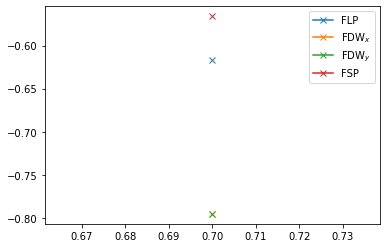

In [6]:
delta_t_index = 0
print('tx =', tx_arr[delta_t_index], ' ty =', ty_arr[delta_t_index])

plt.plot(V_0_arr, e_arr[0,delta_t_index].real+2, marker='x', label=r'FLP')
plt.plot(V_0_arr, e_arr[1,delta_t_index].real+2, marker='x', label=r'FDW$_x$')
plt.plot(V_0_arr, e_arr[2,delta_t_index].real+2, marker='x', label=r'FDW$_y$')
plt.plot(V_0_arr, e_arr[3,delta_t_index].real+2, marker='x', label=r'FSP')

plt.legend()